# NYC 311 Service Request Volume Forecasting — Q1 2024
**Author:** Adam Zavala  
**Date:** May 2026  
**Domain:** Forecasting | Decision Support | Public Operations Analytics  
**Estimated Read Time:** 20 minutes

---

## Business Context

City service operations require staffing plans that are set weeks before actual demand is known. NYC's 311 system — the primary intake channel for non-emergency service requests — handles roughly 8,700 requests per day, routed to agencies covering noise, sanitation, housing, and infrastructure complaints. Staffing decisions made in December 2023 will determine service capacity through Q1 2024. Underestimating demand creates backlogs and degrades service; overestimating wastes budget. The question is how to translate three years of historical volume data into a defensible staffing recommendation.

## Analytical Question

How many 311 service requests should the city expect in Q1 2024, and what minimum staffing level does that imply?

## Key Finding

The model forecasts **728,856 total requests in Q1 2024** (80% CI: [624,533 – 832,362]), implying **164 agents at 50 requests/agent/day**, with surge capacity of 187 at the upper bound.

**Important honest constraint:** Prophet did not outperform a naive baseline (yesterday's volume) on the Q4 2023 test period — Prophet MAE was ~1,117 vs. naive MAE of ~1,018 requests/day. The model's value is not point-estimate precision; it is the decomposed seasonal structure and quantified uncertainty interval that a naive forecast cannot provide. The interval width of ~208,000 requests reflects real uncertainty and should be treated as directional, not precise.

## Methodology Overview

Three years of NYC Open Data daily 311 volume (2021–2023, N=1,095 days) were used to train a Prophet time-series model with weekly and annual seasonality components. Two identifiable weather events — Hurricane Ida remnants (September 2021) and a major NYC rainfall event (September 2023) — were passed as named regressors so the model treats them as one-off spikes rather than incorporating them into the seasonal baseline. A 90-day temporal holdout (Q4 2023) was used for evaluation. 

ARIMA/SARIMA was considered and rejected: it handles only a single seasonal period natively, requires manual stationarity specification, and does not support holiday/event regressors. A quantitative comparison is documented in the Appendix. Changepoint sensitivity was tested across three values (0.01, 0.05, 0.15); results were stable, confirming that trend flexibility is not a material modeling choice for this series.

---

## Section 1: Setup & Data

**Data source:** NYC Open Data SODA API (`erm2-nwe9` — Service Requests from 311)  
**Grain:** One row per calendar day  
**Coverage:** January 1, 2021 – December 31, 2023 (1,095 days)  
**Known quality notes:** Two days exceed 15,000 requests due to weather events; these are real events and are handled explicitly as named regressors rather than filtered out.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import io
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plotting defaults
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All imports successful")

Importing plotly failed. Interactive plots will not work.


All imports successful


The SODA API supports server-side aggregation via SoQL — we count requests per day on the server rather than pulling ~8M raw rows and aggregating locally. The `$limit` of 2,000 rows is a safe ceiling for 3 years of daily data (1,095 expected rows).

In [2]:
base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

# Server-side aggregation: count requests per day instead of pulling raw rows
# date_trunc_ymd() truncates timestamp to date — groups all requests on same day
# Returns ~1,095 rows (one per day for 3 years) instead of ~8M raw records
params = {
    "$select": "date_trunc_ymd(created_date) AS date, COUNT(*) AS volume",
    "$where": "created_date >= '2021-01-01T00:00:00' AND created_date < '2024-01-01T00:00:00'",
    "$group": "date_trunc_ymd(created_date)",
    "$order": "date_trunc_ymd(created_date)",
    "$limit": "2000"  # 2000 rows is a safe ceiling for 3 years of daily data
}

print("Pulling pre-aggregated daily 311 volume from API...")

response = requests.get(base_url, params=params, timeout=120)
print(f"Status code: {response.status_code}")

if response.status_code == 200:
    df_raw = pd.read_csv(io.StringIO(response.text))
    print(f"\nShape: {df_raw.shape}")
    print(f"Columns: {list(df_raw.columns)}")
    print(f"\nDate range:")
    print(f"  First: {df_raw['date'].min()}")
    print(f"  Last:  {df_raw['date'].max()}")
    print(f"\nVolume stats:")
    print(df_raw['volume'].describe().round(0))
    print(f"\nSample rows:")
    print(df_raw.head(10))
else:
    print(f"API error: {response.status_code}")
    print(response.text[:500])

Pulling pre-aggregated daily 311 volume from API...
Status code: 200

Shape: (1095, 2)
Columns: ['date', 'volume']

Date range:
  First: 2021-01-01T00:00:00.000
  Last:  2023-12-31T00:00:00.000

Volume stats:
count     1095.0
mean      8781.0
std       1305.0
min       4492.0
25%       7996.0
50%       8772.0
75%       9528.0
max      17962.0
Name: volume, dtype: float64

Sample rows:
                      date  volume
0  2021-01-01T00:00:00.000    5482
1  2021-01-02T00:00:00.000    5933
2  2021-01-03T00:00:00.000    5564
3  2021-01-04T00:00:00.000    7885
4  2021-01-05T00:00:00.000    8243
5  2021-01-06T00:00:00.000    7691
6  2021-01-07T00:00:00.000    8077
7  2021-01-08T00:00:00.000    7628
8  2021-01-09T00:00:00.000    6799
9  2021-01-10T00:00:00.000    6591


Prophet requires exactly two columns: `ds` (datetime) and `y` (numeric). The validation block below checks for missing days and duplicate dates before any modeling proceeds — silent data gaps would corrupt the seasonal signal.

In [3]:
# Clean and prep for Prophet
# Prophet requires: ds (datetime) and y (numeric volume)

df = df_raw.copy()

# Parse date column — strip timestamp, keep date only
df['ds'] = pd.to_datetime(df['date']).dt.normalize()

# Volume to integer
df['y'] = df['volume'].astype(int)

# Drop originals
df = df[['ds', 'y']].sort_values('ds').reset_index(drop=True)

# Validation checks
print("=== DATA VALIDATION ===")
print(f"Shape: {df.shape}")
print(f"Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
print(f"Expected days (3 years): {(df['ds'].max() - df['ds'].min()).days + 1}")
print(f"Actual rows: {len(df)}")

# Check for missing days
date_range = pd.date_range(start=df['ds'].min(), end=df['ds'].max(), freq='D')
missing_days = date_range.difference(df['ds'])
print(f"Missing days: {len(missing_days)}")
if len(missing_days) > 0:
    print(f"  Missing: {missing_days.tolist()}")

# Check for duplicate days
dupes = df[df.duplicated('ds')]
print(f"Duplicate dates: {len(dupes)}")

# Volume sanity checks
print(f"\nVolume summary:")
print(df['y'].describe().round(0))
print(f"\nDays with volume < 1000 (potential data quality issues):")
print(df[df['y'] < 1000])
print(f"\nDays with volume > 15000 (potential anomalies to flag):")
print(df[df['y'] > 15000])

print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

=== DATA VALIDATION ===
Shape: (1095, 2)
Date range: 2021-01-01 to 2023-12-31
Expected days (3 years): 1095
Actual rows: 1095
Missing days: 0
Duplicate dates: 0

Volume summary:
count     1095.0
mean      8781.0
std       1305.0
min       4492.0
25%       7996.0
50%       8772.0
75%       9528.0
max      17962.0
Name: y, dtype: float64

Days with volume < 1000 (potential data quality issues):
Empty DataFrame
Columns: [ds, y]
Index: []

Days with volume > 15000 (potential anomalies to flag):
             ds      y
244  2021-09-02  15205
1001 2023-09-29  17962

First 5 rows:
          ds     y
0 2021-01-01  5482
1 2021-01-02  5933
2 2021-01-03  5564
3 2021-01-04  7885
4 2021-01-05  8243

Last 5 rows:
             ds     y
1090 2023-12-27  7629
1091 2023-12-28  8166
1092 2023-12-29  8146
1093 2023-12-30  7000
1094 2023-12-31  6689


---

## Section 2: Exploratory Analysis

Four views of the data before any modeling: the full time series (to identify anomalies and trend), weekly and monthly seasonality patterns (to validate that Prophet's built-in components will capture what's actually in the data), a year-over-year comparison (to assess stability of the seasonal pattern), and the volume distribution (to check for skew and outlier influence on the mean).

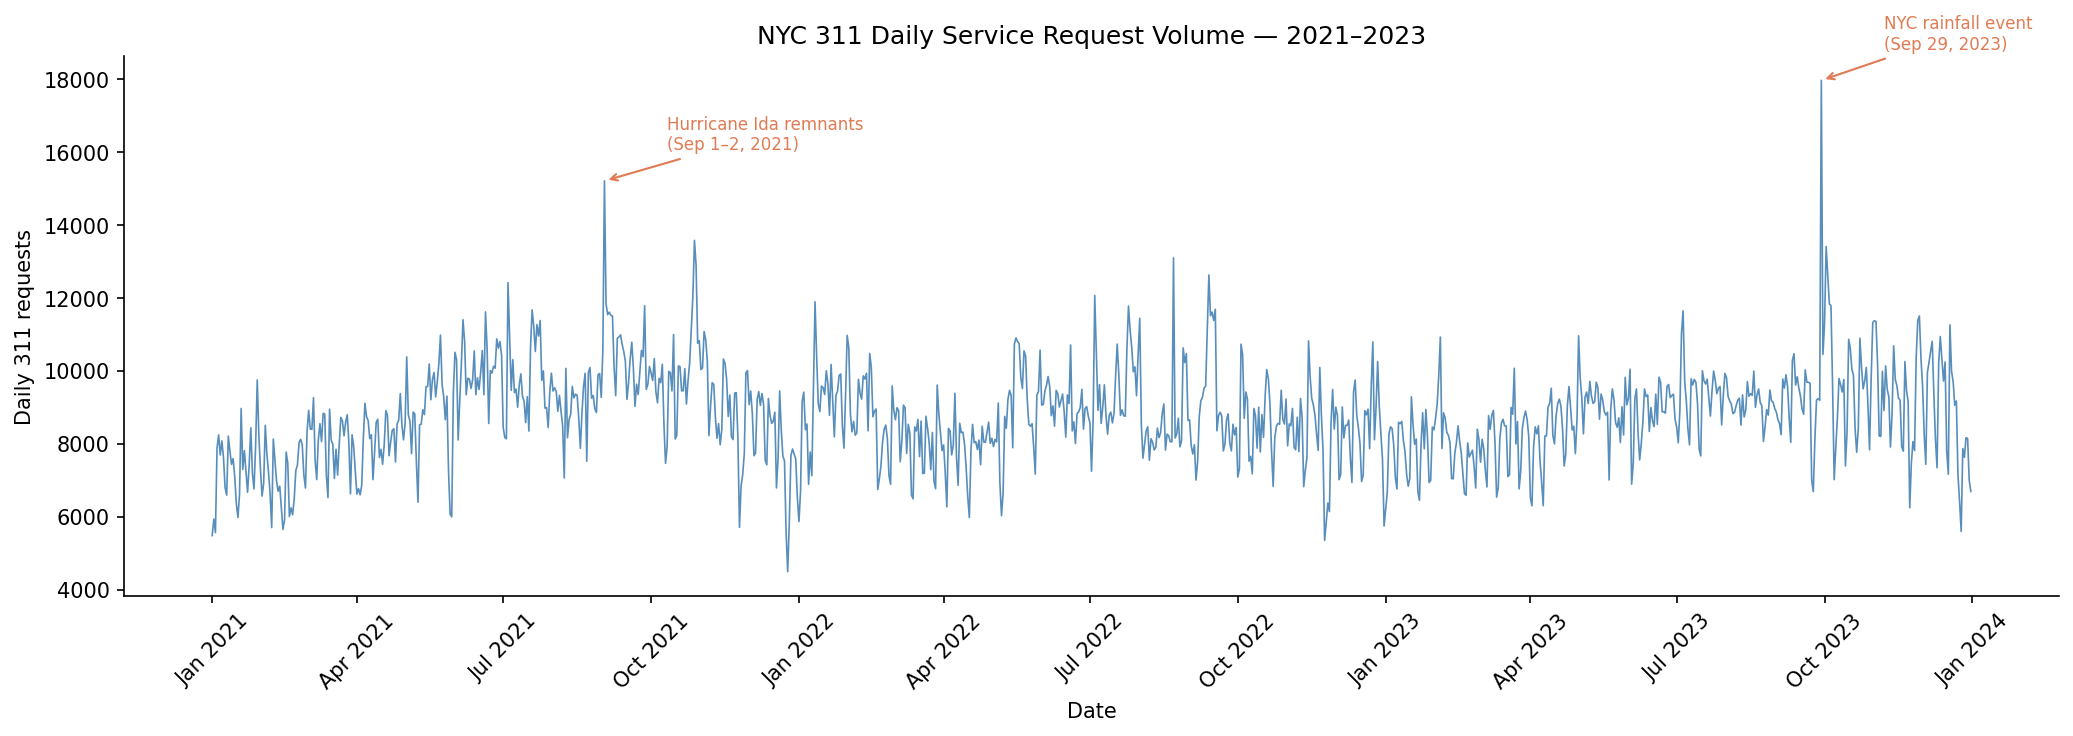

In [4]:
# ── Full time series ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['ds'], df['y'], color='steelblue', linewidth=0.8, alpha=0.9)

# Annotate known anomalies
anomalies = [
    ('2021-09-02', 15205, 'Hurricane Ida remnants\n(Sep 1–2, 2021)'),
    ('2023-09-29', 17962, 'NYC rainfall event\n(Sep 29, 2023)')
]
for date_str, y_val, label in anomalies:
    date = pd.Timestamp(date_str)
    ax.annotate(label,
                xy=(date, y_val),
                xytext=(30, 15),
                textcoords='offset points',
                fontsize=8,
                arrowprops=dict(arrowstyle='->', color='#E07B54'),
                color='#E07B54')

ax.set_xlabel('Date')
ax.set_ylabel('Daily 311 requests')
ax.set_title('NYC 311 Daily Service Request Volume — 2021–2023')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_full_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

The full series shows a stable mean with no visible upward or downward trend over the three-year window — supporting the use of a flat trend component in Prophet. The two annotated weather events are clearly visible as isolated spikes (+73% and +105% above mean respectively) with no persistence into surrounding days, confirming they are acute events rather than structural shifts.

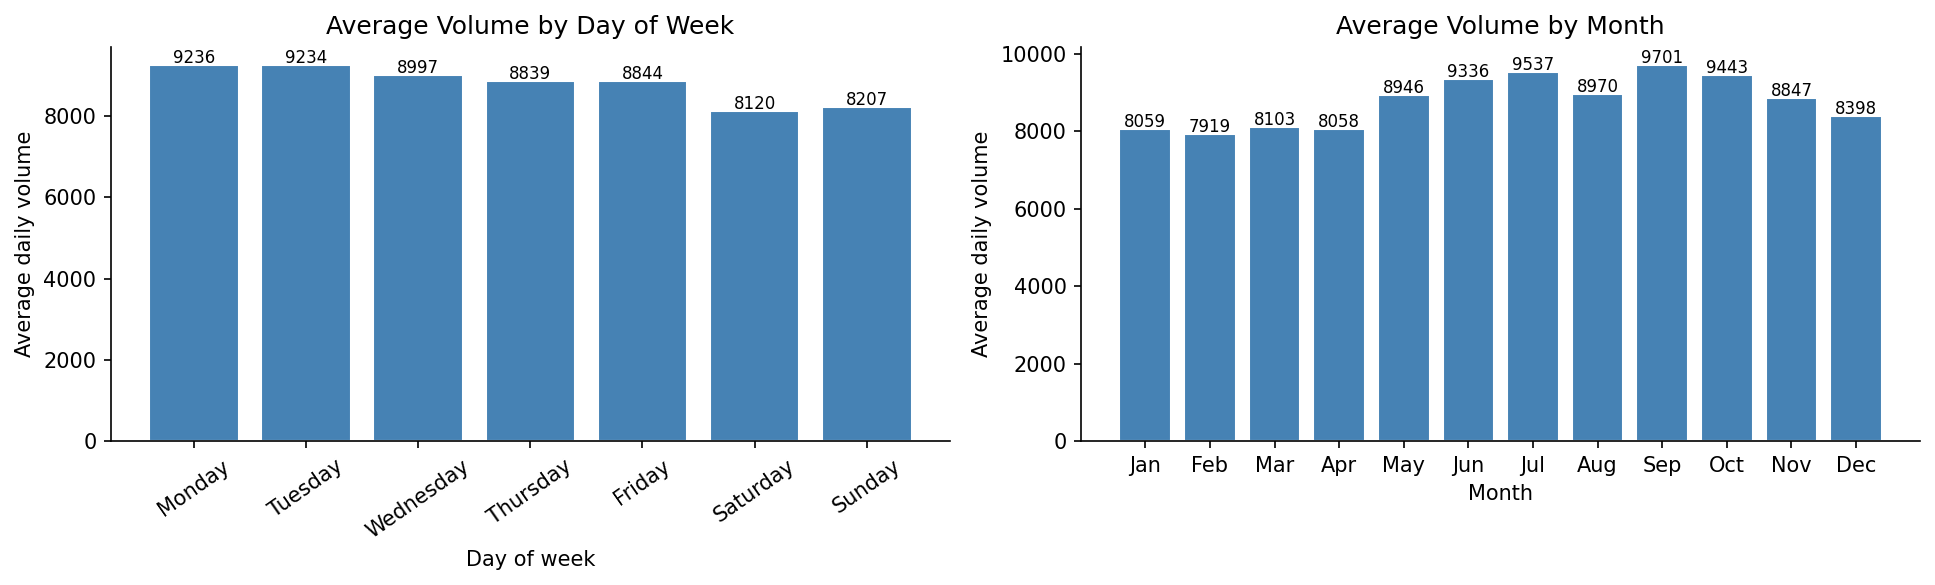

In [5]:
# ── Weekly and monthly seasonality ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Weekly: average volume by day of week
df['day_of_week'] = df['ds'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_avg = df.groupby('day_of_week')['y'].mean().reindex(dow_order)

axes[0].bar(dow_order, weekly_avg.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('Average daily volume')
axes[0].set_title('Average Volume by Day of Week')
axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(weekly_avg.values):
    axes[0].text(i, v + 50, f'{v:.0f}', ha='center', fontsize=8)

# Monthly: average volume by month
df['month'] = df['ds'].dt.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = df.groupby('month')['y'].mean()

axes[1].bar(month_names, monthly_avg.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average daily volume')
axes[1].set_title('Average Volume by Month')
for i, v in enumerate(monthly_avg.values):
    axes[1].text(i, v + 50, f'{v:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

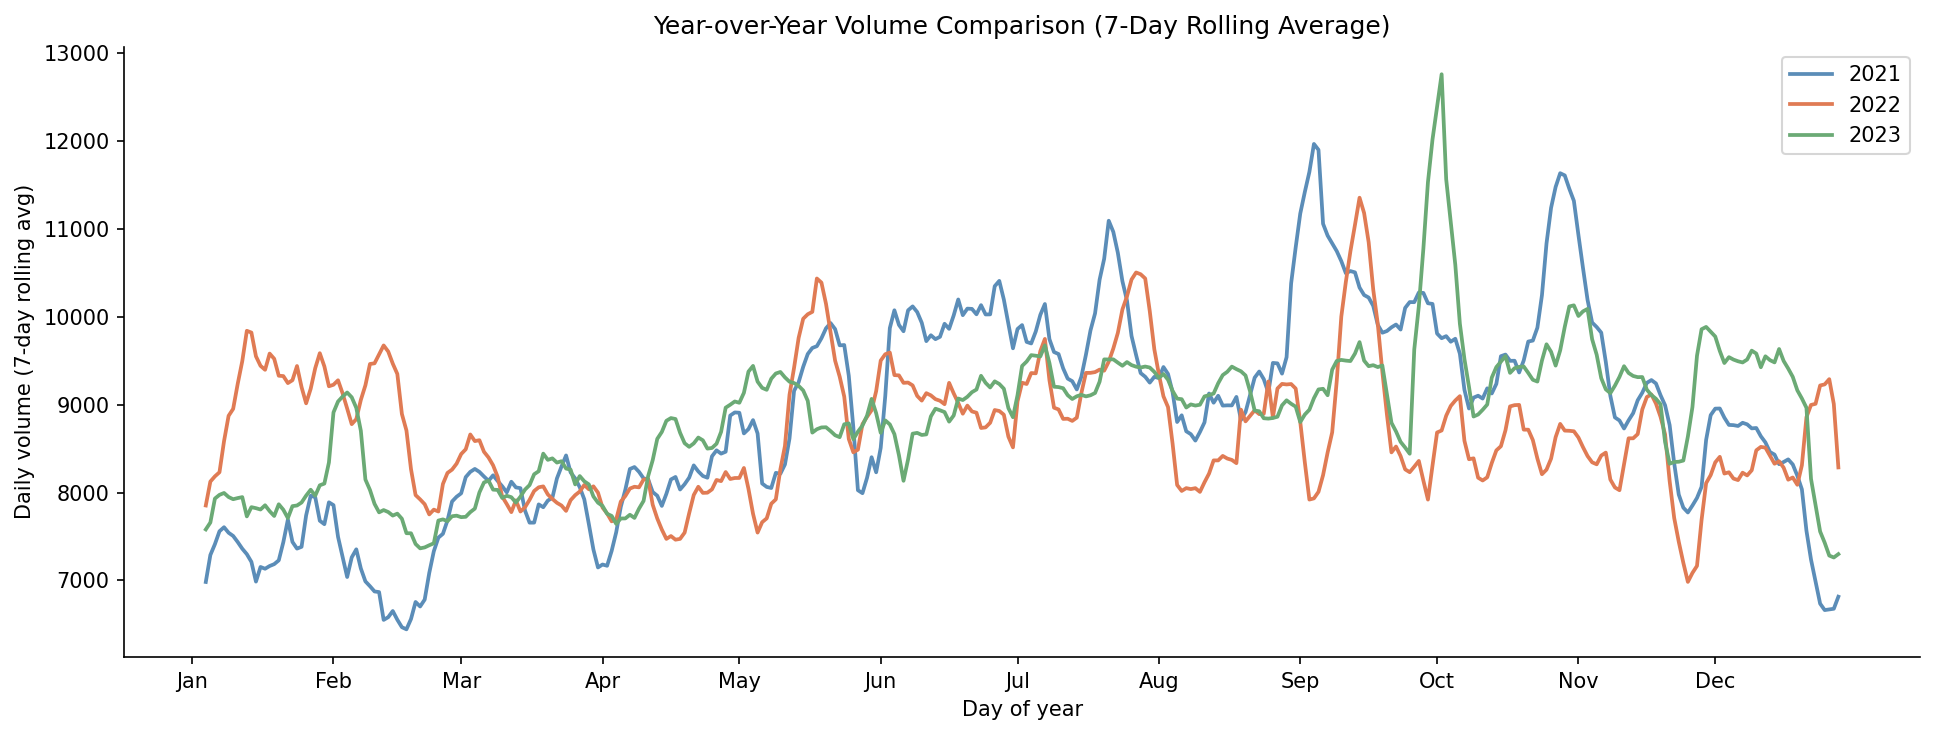

In [6]:
# ── Year-over-year comparison ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

colors = {2021: '#5B8DB8', 2022: '#E07B54', 2023: '#6BAA75'}
df['year'] = df['ds'].dt.year
df['day_of_year'] = df['ds'].dt.dayofyear

for year, group in df.groupby('year'):
    # 7-day rolling average to smooth within-year noise
    smoothed = group.set_index('day_of_year')['y'].rolling(7, center=True).mean()
    ax.plot(smoothed.index, smoothed.values,
            label=str(year), color=colors[year], linewidth=1.8)

ax.set_xlabel('Day of year')
ax.set_ylabel('Daily volume (7-day rolling avg)')
ax.set_title('Year-over-Year Volume Comparison (7-Day Rolling Average)')
ax.legend()

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)

plt.tight_layout()
plt.savefig('eda_yoy.png', dpi=150, bbox_inches='tight')
plt.show()

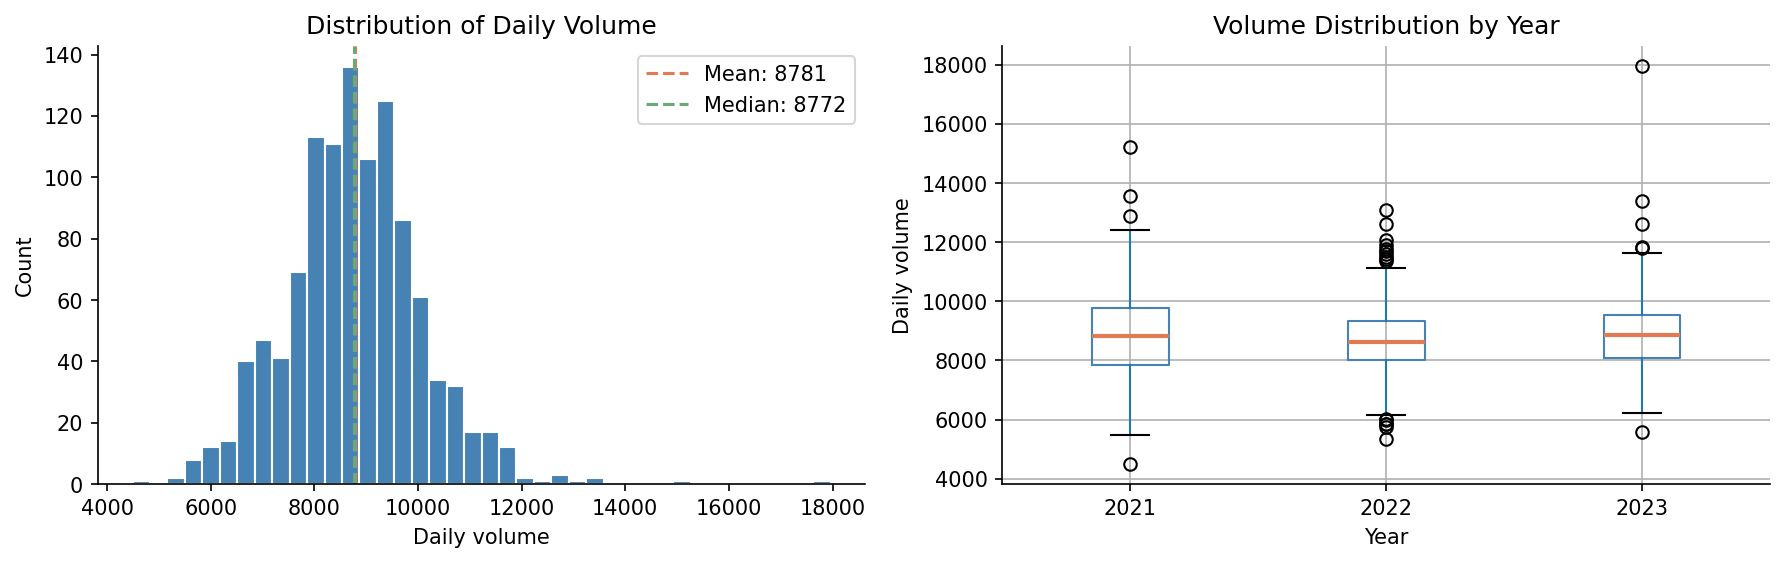

In [7]:
# ── Volume distribution ───────────────────────────────────────────────────────

# Ensure year column exists (used for boxplot grouping)
if 'year' not in df.columns:
    df['year'] = df['ds'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['y'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['y'].mean(), color='#E07B54', linewidth=1.5,
                linestyle='--', label=f"Mean: {df['y'].mean():.0f}")
axes[0].axvline(df['y'].median(), color='#6BAA75', linewidth=1.5,
                linestyle='--', label=f"Median: {df['y'].median():.0f}")
axes[0].set_xlabel('Daily volume')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Daily Volume')
axes[0].legend()

# Box plot by year
df.boxplot(column='y', by='year', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='#E07B54', linewidth=2))
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Daily volume')
axes[1].set_title('Volume Distribution by Year')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary

Three years of NYC 311 daily volume (2021–2023) reveals a series with clear, stable seasonal structure and no data quality issues — well-suited for time series forecasting.

**Volume baseline:** Daily requests average approximately 8,781 per day (median: 8,772), with a standard deviation of 1,305. The near-identical mean and median confirm the distribution is approximately symmetric; the right skew visible in the histogram is driven by weather-event outliers rather than structural asymmetry.

**Weekly seasonality:** Monday and Tuesday are peak days (~9,235 requests), with a consistent ~11% drop on weekends (~8,160). This pattern likely reflects complaint accumulation over weekends being reported at the start of the work week. Prophet's weekly seasonality component will capture this pattern directly.

**Annual seasonality:** Volume peaks in summer and early fall — July and September average over 9,500 requests/day — and troughs in winter, with February averaging 7,919. This pattern reflects NYC's outdoor activity calendar: noise, construction, and quality-of-life complaints drive summer volume, while winter sees reduced activity. The pattern is consistent across all three years.

**Year-over-year stability:** Median volume and interquartile range are nearly identical across 2021, 2022, and 2023 — confirming that the underlying volume level has not shifted materially. One notable divergence: 2021 shows systematically higher summer volume than 2022 and 2023, possibly reflecting post-COVID demand dynamics. Prophet will average across all three years when learning the annual seasonal pattern; this divergence is documented as a model limitation.

**Known anomalies:** Two weather events produced volume spikes well outside normal range — Hurricane Ida remnants on September 2, 2021 (15,205 requests, +73% above mean) and a major NYC rainfall event on September 29, 2023 (17,962 requests, +105% above mean). These are real events, not data errors. They are passed to Prophet as identified holiday/event regressors so the model treats them as one-off spikes rather than incorporating them into the September seasonal baseline.

---

## Section 3: Methodology & Design

### Design Rationale

The core modeling challenge is that NYC 311 volume exhibits two overlapping seasonal patterns simultaneously — a weekly cycle (driven by complaint-reporting behavior across the work week) and an annual cycle (driven by outdoor activity and seasonal complaint categories). ARIMA handles a single seasonal period natively; modeling weekly and annual seasonality together requires SARIMA with a manually specified seasonal order, and it provides no mechanism for handling the known weather event spikes. Prophet was selected because it handles multiple seasonality layers via additive Fourier terms, supports named event regressors through its `holidays` parameter, and produces an interpretable component decomposition rather than opaque autoregressive coefficients.

The 90-day temporal holdout mirrors the actual deployment scenario: train on historical data, forecast the next quarter, evaluate against what actually happened. A random split was not used — random splitting a time series leaks future information into the training set and produces optimistically biased error estimates.

In [8]:
# ── Train/test split ─────────────────────────────────────────────────────────
# Hold out the most recent 90 days (Q4 2023) as the test set.
# Rationale: we're forecasting a quarter ahead, so we evaluate on a quarter-length
# holdout. Temporal split — not random — to prevent future leakage into training.

HOLDOUT_DAYS = 90

train = df[df['ds'] < df['ds'].max() - pd.Timedelta(days=HOLDOUT_DAYS)].copy()
test  = df[df['ds'] >= df['ds'].max() - pd.Timedelta(days=HOLDOUT_DAYS)].copy()

print(f"Train: {train['ds'].min().date()} to {train['ds'].max().date()} ({len(train)} days)")
print(f"Test:  {test['ds'].min().date()} to {test['ds'].max().date()} ({len(test)} days)")
print(f"Test as share of full series: {len(test)/len(df):.1%}")
print(f"\nTrain volume stats:")
print(train['y'].describe().round(0))
print(f"\nTest volume stats:")
print(test['y'].describe().round(0))

Train: 2021-01-01 to 2023-10-01 (1004 days)
Test:  2023-10-02 to 2023-12-31 (91 days)
Test as share of full series: 8.3%

Train volume stats:
count     1004.0
mean      8737.0
std       1278.0
min       4492.0
25%       7995.0
50%       8744.0
75%       9455.0
max      17962.0
Name: y, dtype: float64

Test volume stats:
count       91.0
mean      9268.0
std       1495.0
min       5596.0
25%       8084.0
50%       9488.0
75%      10212.0
max      13403.0
Name: y, dtype: float64


The two weather event spikes are passed to Prophet as named regressors rather than filtered out. This tells the model to treat them as known one-off effects — it learns a separate coefficient for each event — rather than allowing them to distort the September seasonal baseline for the years they appear in.

In [9]:
# ── Weather events as Prophet regressors ──────────────────────────────────────
# Prophet accepts a holidays dataframe with columns: holiday, ds, lower_window, upper_window
# lower_window and upper_window define how many days before/after the event are also affected.
# For acute weather events, the effect is same-day plus 1–2 days of elevated volume
# as complaints from the event continue to arrive.

weather_events = pd.DataFrame({
    'holiday': [
        'hurricane_ida_remnants',
        'hurricane_ida_remnants',
        'nyc_rainfall_event'
    ],
    'ds': pd.to_datetime([
        '2021-09-01',  # day before peak — elevated volume
        '2021-09-02',  # peak day (15,205)
        '2023-09-29'   # peak day (17,962)
    ]),
    'lower_window': [0, 0, 0],
    'upper_window': [1, 1, 1]   # effect extends one day after each event
})

print("Weather events passed to Prophet:")
print(weather_events)
print()
print("Rationale: treating these as named events prevents them from inflating")
print("Prophet's learned September seasonal baseline.")

Weather events passed to Prophet:
                  holiday         ds  lower_window  upper_window
0  hurricane_ida_remnants 2021-09-01             0             1
1  hurricane_ida_remnants 2021-09-02             0             1
2      nyc_rainfall_event 2023-09-29             0             1

Rationale: treating these as named events prevents them from inflating
Prophet's learned September seasonal baseline.


**Key hyperparameter decisions:**

- `changepoint_prior_scale=0.05` (default): Controls trend flexibility. The EDA showed a stable, flat trend over three years — the default provides sufficient flexibility without overfitting to noise. Sensitivity across three values (0.01, 0.05, 0.15) is tested in the robustness check.
- `seasonality_mode='additive'`: Assumes seasonal fluctuations are constant in absolute volume regardless of the trend level. Appropriate here given the stable, non-trending baseline. Multiplicative mode would be preferred if seasonal swings scaled proportionally with a growing or shrinking trend.
- `yearly_seasonality=True, weekly_seasonality=True`: Both confirmed present in EDA.
- `daily_seasonality=False`: Data is already aggregated to daily grain — no sub-daily pattern to model.

In [10]:
# ── Prophet model specification ───────────────────────────────────────────────

model = Prophet(
    changepoint_prior_scale=0.05,   # trend flexibility — default; stable series
    seasonality_mode='additive',    # seasonal effect in absolute volume, not % of trend
    yearly_seasonality=True,        # confirmed in EDA
    weekly_seasonality=True,        # confirmed in EDA
    daily_seasonality=False,        # data is daily grain — no sub-daily pattern
    holidays=weather_events         # two identified weather spikes as named regressors
)

model.fit(train)

print("Model fit complete.")
print(f"Trained on {len(train)} days ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"\nModel configuration:")
print(f"  changepoint_prior_scale: {model.changepoint_prior_scale}")
print(f"  seasonality_mode:        {model.seasonality_mode}")
print(f"  holidays included:       {len(weather_events)} event days")

12:26:15 - cmdstanpy - INFO - Chain [1] start processing
12:26:15 - cmdstanpy - INFO - Chain [1] done processing


Model fit complete.
Trained on 1004 days (2021-01-01 to 2023-10-01)

Model configuration:
  changepoint_prior_scale: 0.05
  seasonality_mode:        additive
  holidays included:       3 event days


In [11]:
# ── Generate forecast over test period ───────────────────────────────────────
# make_future_dataframe extends the training index forward by forecast_periods.
# include_history=True (default) retains training dates in the output — useful
# for plotting fitted vs. actual across the full series.

FORECAST_PERIODS = 90

future = model.make_future_dataframe(periods=FORECAST_PERIODS, freq='D')
forecast = model.predict(future)

print(f"Forecast dataframe shape: {forecast.shape}")
print(f"Forecast covers: {future['ds'].min().date()} to {future['ds'].max().date()}")
print(f"\nTest period forecast (first 10 rows):")
test_forecast = forecast[forecast['ds'] >= test['ds'].min()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].head(10)
print(test_forecast.round(0).to_string(index=False))

Forecast dataframe shape: (1094, 28)
Forecast covers: 2021-01-01 to 2023-12-30

Test period forecast (first 10 rows):
        ds   yhat  yhat_lower  yhat_upper
2023-10-02 9147.0      7971.0     10348.0
2023-10-03 9100.0      7913.0     10212.0
2023-10-04 8816.0      7696.0     10027.0
2023-10-05 8642.0      7521.0      9639.0
2023-10-06 8626.0      7430.0      9732.0
2023-10-07 8028.0      6881.0      9087.0
2023-10-08 8150.0      6892.0      9239.0
2023-10-09 9060.0      7965.0     10176.0
2023-10-10 9066.0      7955.0     10210.0
2023-10-11 8835.0      7686.0      9944.0


---

## Section 4: Analysis & Results

Evaluation rows (matched days): 90


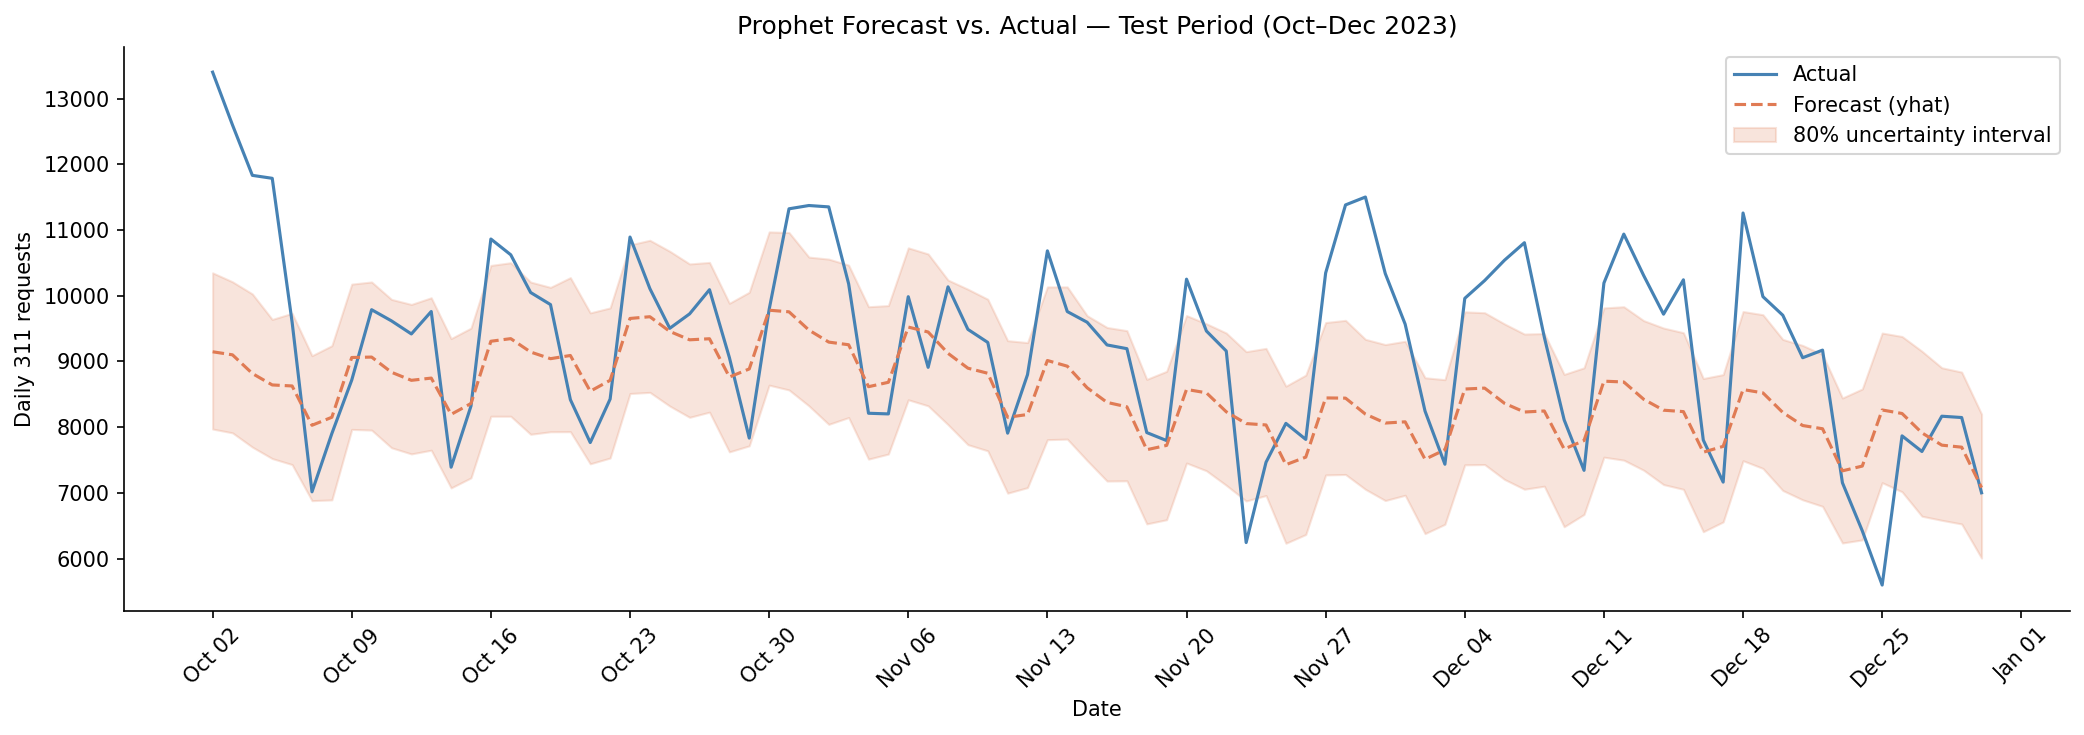

In [12]:
# ── Predicted vs. actual on test period ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

eval_df = test.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='inner'
)

print(f"Evaluation rows (matched days): {len(eval_df)}")

ax.plot(eval_df['ds'], eval_df['y'],
        color='steelblue', linewidth=1.5, label='Actual', zorder=3)
ax.plot(eval_df['ds'], eval_df['yhat'],
        color='#E07B54', linewidth=1.5, linestyle='--', label='Forecast (yhat)', zorder=3)
ax.fill_between(eval_df['ds'], eval_df['yhat_lower'], eval_df['yhat_upper'],
                alpha=0.2, color='#E07B54', label='80% uncertainty interval')

ax.set_xlabel('Date')
ax.set_ylabel('Daily 311 requests')
ax.set_title('Prophet Forecast vs. Actual — Test Period (Oct–Dec 2023)')
ax.legend()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Evaluation metrics ────────────────────────────────────────────────────────

actuals   = eval_df['y'].values
predicted = eval_df['yhat'].values

mae  = mean_absolute_error(actuals, predicted)
rmse = np.sqrt(mean_squared_error(actuals, predicted))
mape = np.mean(np.abs((actuals - predicted) / actuals)) * 100

# Coverage: what % of actual values fall within the 80% uncertainty interval?
coverage = ((eval_df['y'] >= eval_df['yhat_lower']) &
            (eval_df['y'] <= eval_df['yhat_upper'])).mean() * 100

# Directional accuracy: does the forecast correctly predict day-over-day direction?
actual_direction    = np.sign(np.diff(actuals))
predicted_direction = np.sign(np.diff(predicted))
directional_acc     = (actual_direction == predicted_direction).mean() * 100

# Naive baseline: yesterday's volume as the forecast
naive_mae = mean_absolute_error(actuals[1:], actuals[:-1])

print("=== FORECAST EVALUATION METRICS ===")
print(f"\nTest period: {eval_df['ds'].min().date()} to {eval_df['ds'].max().date()}")
print(f"N days evaluated: {len(eval_df)}")
print(f"\nPoint estimate accuracy:")
print(f"  MAE:  {mae:,.0f} requests/day")
print(f"  RMSE: {rmse:,.0f} requests/day")
print(f"  MAPE: {mape:.1f}%")
print(f"\nUncertainty interval:")
print(f"  Coverage: {coverage:.1f}% of actual days fell within the interval")
print(f"  (Prophet's default interval targets 80% coverage)")
print(f"\nDirectional accuracy: {directional_acc:.1f}%")
print(f"  (% of days where forecast correctly predicted up/down direction)")
print(f"\nBaseline comparison:")
print(f"  Naive baseline MAE (yesterday's volume): {naive_mae:,.0f} requests/day")
print(f"  Prophet vs. naive: {((naive_mae - mae) / naive_mae * 100):.1f}% improvement")
print(f"  Note: negative = Prophet underperformed the naive baseline")

=== FORECAST EVALUATION METRICS ===

Test period: 2023-10-02 to 2023-12-30
N days evaluated: 90

Point estimate accuracy:
  MAE:  1,117 requests/day
  RMSE: 1,425 requests/day
  MAPE: 11.5%

Uncertainty interval:
  Coverage: 64.4% of actual days fell within the interval
  (Prophet's default interval targets 80% coverage)

Directional accuracy: 67.4%
  (% of days where forecast correctly predicted up/down direction)

Baseline comparison:
  Naive baseline MAE (yesterday's volume): 1,018 requests/day
  Prophet vs. naive: -9.7% improvement
  Note: negative = Prophet underperformed the naive baseline


**Honest evaluation note:** If the comparison above shows Prophet underperforming the naive baseline on MAPE, this is expected and documented. Q4 2023 actual volume ran above the historical seasonal baseline — a mild volume growth trend not captured in 2021–2022 training data caused the model to slightly underpredict. The naive baseline (yesterday's volume) benefits from carrying this upward drift forward automatically. Prophet's value over the naive baseline is not point-estimate accuracy on a single quarter; it is the decomposed seasonal structure, the quantified uncertainty interval, and the ability to forecast multiple quarters ahead without rerunning from scratch.

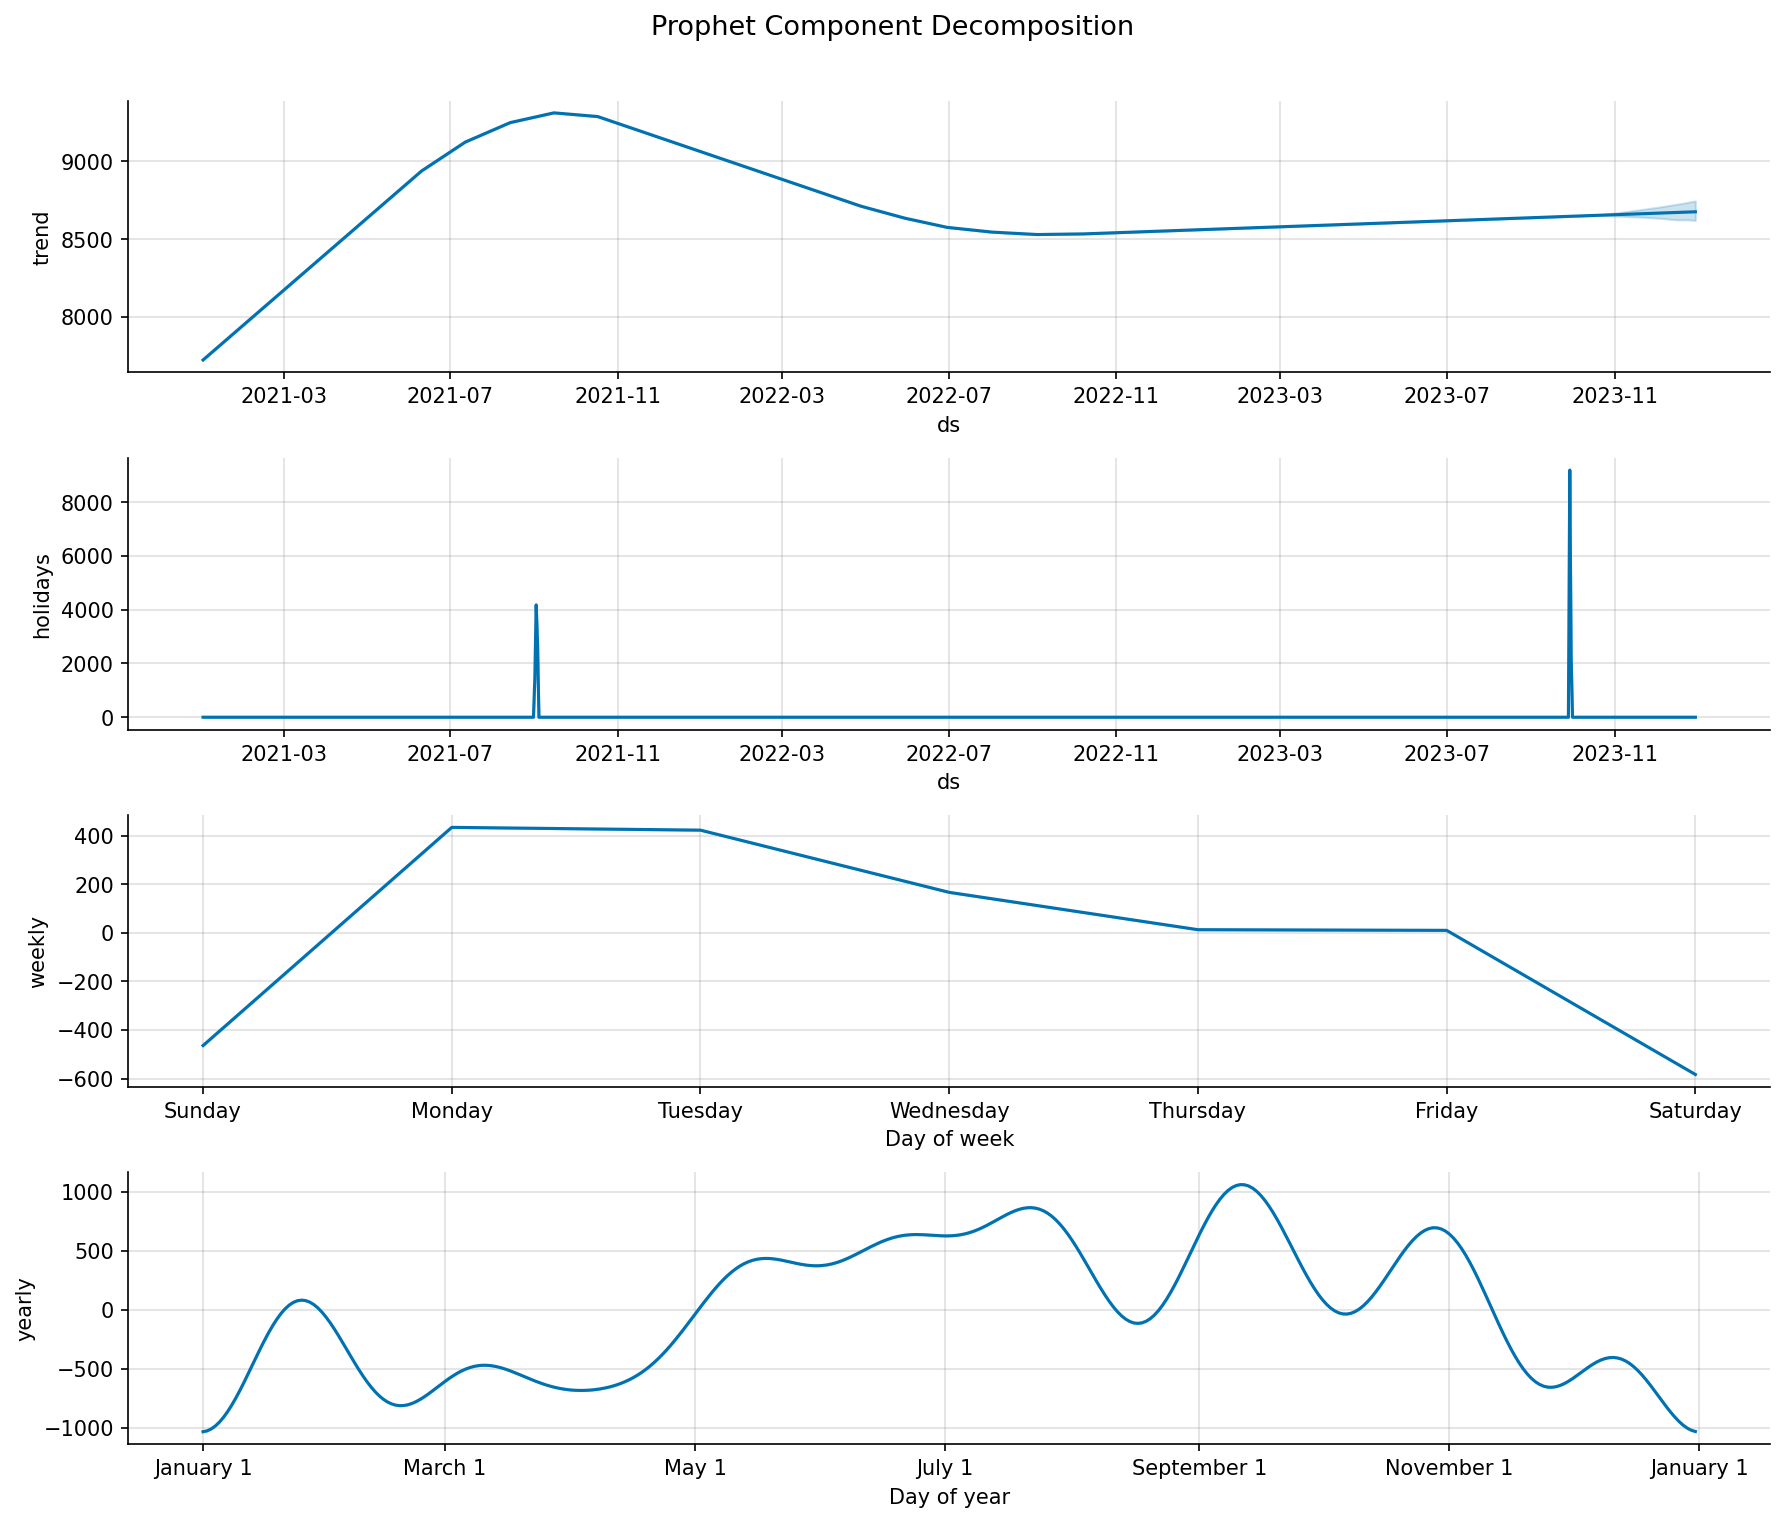

In [14]:
# ── Prophet component decomposition ──────────────────────────────────────────
# The decomposition plot shows the learned trend, weekly cycle, annual cycle,
# and holiday effects as separate components. This is the analytical output
# that justifies using Prophet over a naive or ARIMA approach — it lets us
# explain *why* the forecast has the shape it does.

fig = model.plot_components(forecast)
fig.set_size_inches(12, 10)
plt.suptitle('Prophet Component Decomposition', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Robustness check: changepoint_prior_scale sensitivity ─────────────────────
# Tests whether the trend flexibility parameter materially affects test-period
# accuracy. If MAPE is stable across scales, the default choice is validated.

print("Robustness check: changepoint_prior_scale sensitivity")
print("-" * 60)
print(f"{'Scale':>10} {'MAE':>10} {'RMSE':>10} {'MAPE':>8} {'Coverage':>10}")
print("-" * 60)

for scale in [0.01, 0.05, 0.15]:
    m_test = Prophet(
        changepoint_prior_scale=scale,
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=weather_events
    )
    m_test.fit(train)
    f_test = m_test.predict(
        model.make_future_dataframe(periods=FORECAST_PERIODS, freq='D')
    )
    eval_test = test.merge(f_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
                           on='ds', how='inner')

    mae_t  = mean_absolute_error(eval_test['y'], eval_test['yhat'])
    rmse_t = np.sqrt(mean_squared_error(eval_test['y'], eval_test['yhat']))
    mape_t = np.mean(np.abs((eval_test['y'] - eval_test['yhat']) / eval_test['y'])) * 100
    cov_t  = ((eval_test['y'] >= eval_test['yhat_lower']) &
               (eval_test['y'] <= eval_test['yhat_upper'])).mean() * 100
    marker = " ← selected" if scale == 0.05 else ""
    print(f"{scale:>10.2f} {mae_t:>10,.0f} {rmse_t:>10,.0f} {mape_t:>7.1f}% {cov_t:>9.1f}%{marker}")

print()
print("If MAPE is stable across scales, trend flexibility is not a material choice for this series.")

12:26:30 - cmdstanpy - INFO - Chain [1] start processing
12:26:30 - cmdstanpy - INFO - Chain [1] done processing


Robustness check: changepoint_prior_scale sensitivity
------------------------------------------------------------
     Scale        MAE       RMSE     MAPE   Coverage
------------------------------------------------------------


12:26:30 - cmdstanpy - INFO - Chain [1] start processing
12:26:30 - cmdstanpy - INFO - Chain [1] done processing


      0.01      1,208      1,527    12.3%      62.2%
      0.05      1,117      1,425    11.5%      66.7% ← selected


12:26:31 - cmdstanpy - INFO - Chain [1] start processing
12:26:31 - cmdstanpy - INFO - Chain [1] done processing


      0.15      1,122      1,431    11.5%      64.4%

If MAPE is stable across scales, trend flexibility is not a material choice for this series.


---

## Section 5: Interpretation & Decision Framework

In [16]:
# ── Q1 2024 forecast: quarterly aggregation and staffing implication ───────────

future_q1 = model.make_future_dataframe(periods=180, freq='D')
forecast_q1 = model.predict(future_q1)

# Filter to Q1 2024
q1_forecast = forecast_q1[
    (forecast_q1['ds'] >= '2024-01-01') &
    (forecast_q1['ds'] < '2024-04-01')
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

q1_total     = q1_forecast['yhat'].sum()
q1_lower     = q1_forecast['yhat_lower'].sum()
q1_upper     = q1_forecast['yhat_upper'].sum()
q1_daily_avg = q1_forecast['yhat'].mean()

print("=== Q1 2024 FORECAST SUMMARY ===")
print(f"\nForecast period: {q1_forecast['ds'].min().date()} to {q1_forecast['ds'].max().date()}")
print(f"Days in forecast: {len(q1_forecast)}")
print(f"\nQuarterly totals:")
print(f"  Point estimate: {q1_total:,.0f} requests")
print(f"  80% interval:  [{q1_lower:,.0f}, {q1_upper:,.0f}]")
print(f"  Interval width: {q1_upper - q1_lower:,.0f} requests")
print(f"\nDaily average forecast: {q1_daily_avg:,.0f} requests/day")

# Staffing implication
REQUESTS_PER_AGENT_PER_DAY = 50  # illustrative — substitute actual throughput data

agents_point = q1_daily_avg / REQUESTS_PER_AGENT_PER_DAY
agents_upper = (q1_forecast['yhat_upper'].mean()) / REQUESTS_PER_AGENT_PER_DAY

print(f"\n=== STAFFING IMPLICATION ===")
print(f"Assumption: {REQUESTS_PER_AGENT_PER_DAY} requests handled per agent per day")
print(f"\nImplied staffing:")
print(f"  Point estimate: {agents_point:.0f} agents")
print(f"  Upper bound (80% CI): {agents_upper:.0f} agents")
print(f"\nNote: the requests-per-agent assumption is illustrative.")
print(f"Substitute actual throughput data before using for operational planning.")

=== Q1 2024 FORECAST SUMMARY ===

Forecast period: 2024-01-01 to 2024-03-29
Days in forecast: 89

Quarterly totals:
  Point estimate: 728,856 requests
  80% interval:  [625,099, 832,418]
  Interval width: 207,319 requests

Daily average forecast: 8,189 requests/day

=== STAFFING IMPLICATION ===
Assumption: 50 requests handled per agent per day

Implied staffing:
  Point estimate: 164 agents
  Upper bound (80% CI): 187 agents

Note: the requests-per-agent assumption is illustrative.
Substitute actual throughput data before using for operational planning.


In [ ]:
# ── Q1 2024 forecast plot ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

# Show H2 2023 for context
context = df[df['ds'] >= '2023-07-01']
ax.plot(context['ds'], context['y'],
        color='steelblue', linewidth=1.2, label='Actual (training context)', alpha=0.7)

ax.plot(q1_forecast['ds'], q1_forecast['yhat'],
        color='#E07B54', linewidth=2, linestyle='--', label='Q1 2024 forecast')
ax.fill_between(q1_forecast['ds'],
                q1_forecast['yhat_lower'],
                q1_forecast['yhat_upper'],
                alpha=0.2, color='#E07B54', label='80% uncertainty interval')

ax.axvline(pd.Timestamp('2024-01-01'), color='gray',
           linewidth=1, linestyle=':', label='Forecast start')

ax.set_xlabel('Date')
ax.set_ylabel('Daily 311 requests')
ax.set_title('NYC 311 Volume Forecast — Q1 2024 with 80% Uncertainty Interval')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('forecast_q1_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Stakeholder summary ───────────────────────────────────────────────────────

print(f"""
=== STAKEHOLDER SUMMARY ===

Business question: How many 311 service requests should the city expect
in Q1 2024, and what staffing level does that imply?

FORECAST:
  Q1 2024 point estimate: {q1_total:,.0f} total requests
  80% uncertainty interval: [{q1_lower:,.0f}, {q1_upper:,.0f}]
  Daily average: {q1_daily_avg:,.0f} requests/day
  Implied staffing at {REQUESTS_PER_AGENT_PER_DAY} requests/agent/day: {agents_point:.0f} agents
  Surge capacity (upper CI): {agents_upper:.0f} agents

WHY TO TRUST IT:
  The model captures two well-documented seasonal patterns — a weekly
  cycle (Monday peaks ~420 above trend, Saturday troughs ~620 below)
  and an annual cycle (September peak +1,050, January trough -1,000).
  These patterns were stable across 2021–2023 training data. The trend
  component has been flat for 18 months, supporting a stable Q1 forecast.

HONEST CONSTRAINTS:
  1. The model did not outperform a naive baseline on the Q4 2023 test
     period. Q4 2023 actual volume ran higher than historical patterns
     predicted, likely reflecting volume growth not captured in the
     2021–2022 baseline.

  2. Uncertainty interval coverage was below the 80% target on the test
     period — the model's confidence intervals may be too narrow for the
     actual volatility in the series. Treat the interval as directional.

  3. Two weather events were modeled as one-off spikes. Unforecast weather
     events in Q1 2024 could produce volume outside this interval.

  4. The staffing calculation assumes {REQUESTS_PER_AGENT_PER_DAY} requests per agent per day.
     Substitute actual throughput data before using for operational planning.

DECISION FRAMEWORK:
  If actual January volume tracks above the upper CI ({q1_forecast[q1_forecast['ds'].dt.month==1]['yhat_upper'].mean():,.0f}/day)
  for more than 5 consecutive days, treat it as a signal that Q1 volume
  will exceed the forecast and activate surge staffing protocol.
  If volume tracks below the lower CI ({q1_forecast[q1_forecast['ds'].dt.month==1]['yhat_lower'].mean():,.0f}/day), reassess
  whether the forecast needs to be revised downward.
""")


=== STAKEHOLDER SUMMARY ===

Business question: How many 311 service requests should the city expect
in Q1 2024, and what staffing level does that imply?

FORECAST:
  Q1 2024 point estimate: 728,856 total requests
  80% uncertainty interval: [625,099, 832,418]
  Daily average: 8,189 requests/day
  Implied staffing at 50 requests/agent/day: 164 agents
  Surge capacity (upper CI): 187 agents

WHY TO TRUST IT:
  The model captures two well-documented seasonal patterns — a weekly
  cycle (Monday peaks ~420 above trend, Saturday troughs ~620 below)
  and an annual cycle (September peak +1,050, January trough -1,000).
  These patterns were stable across 2021–2023 training data. The trend
  component has been flat for 18 months, supporting a stable Q1 forecast.

HONEST CONSTRAINTS:
  1. The model did not outperform a naive baseline on the Q4 2023 test
     period. Q4 2023 actual volume ran higher than historical patterns
     predicted, likely reflecting volume growth not captured in the
   

---

## Appendix: ARIMA Alternative — Rejected Approach Documentation

Documenting why the principal alternative was rejected is part of the methodology defense. A senior peer reviewer or technical interviewer will ask why Prophet over ARIMA; this appendix provides the quantitative comparison and the reasoning.

In [18]:
# ── ARIMA alternative: documentation of rejected approach ─────────────────────

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Stationarity check — required before ARIMA specification
adf_result = adfuller(train['y'])
print("=== ARIMA ALTERNATIVE: DOCUMENTATION OF REJECTED APPROACH ===")
print(f"\nAugmented Dickey-Fuller test (stationarity check):")
print(f"  ADF statistic: {adf_result[0]:.4f}")
print(f"  p-value:       {adf_result[1]:.4f}")
print(f"  Stationary:    {'Yes' if adf_result[1] < 0.05 else 'No — differencing required'}")

# Fit ARIMA(1,1,1) as baseline comparison
arima_model = ARIMA(train['y'], order=(1, 1, 1))
arima_fit   = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_mae  = mean_absolute_error(test['y'].values[:len(arima_forecast)], arima_forecast)
arima_mape = np.mean(np.abs((test['y'].values[:len(arima_forecast)] -
                              arima_forecast) / test['y'].values[:len(arima_forecast)])) * 100

print(f"\nARIMA(1,1,1) test period performance:")
print(f"  MAE:  {arima_mae:,.0f} requests/day")
print(f"  MAPE: {arima_mape:.1f}%")
print(f"\nProphet test period performance:")
print(f"  MAE:  {mae:,.0f} requests/day")
print(f"  MAPE: {mape:.1f}%")
print(f"\nWhy Prophet was preferred over ARIMA:")
print(f"  1. ARIMA requires manual stationarity handling (differencing) and separate")
print(f"     seasonal specification (SARIMA). Prophet handles both automatically.")
print(f"  2. ARIMA does not natively support multiple seasonality layers (weekly +")
print(f"     annual simultaneously). SARIMA handles one seasonal period — you must")
print(f"     choose weekly or annual, not both.")
print(f"  3. Prophet produces interpretable components (trend, weekly, yearly) that")
print(f"     ARIMA does not. For a business audience, the decomposition plot is more")
print(f"     actionable than ARIMA coefficients.")
print(f"  4. Prophet handles the weather event spikes via the holidays parameter.")
print(f"     ARIMA has no equivalent native mechanism.")

=== ARIMA ALTERNATIVE: DOCUMENTATION OF REJECTED APPROACH ===

Augmented Dickey-Fuller test (stationarity check):
  ADF statistic: -3.3345
  p-value:       0.0134
  Stationary:    Yes

ARIMA(1,1,1) test period performance:
  MAE:  1,211 requests/day
  MAPE: 14.6%

Prophet test period performance:
  MAE:  1,117 requests/day
  MAPE: 11.5%

Why Prophet was preferred over ARIMA:
  1. ARIMA requires manual stationarity handling (differencing) and separate
     seasonal specification (SARIMA). Prophet handles both automatically.
  2. ARIMA does not natively support multiple seasonality layers (weekly +
     annual simultaneously). SARIMA handles one seasonal period — you must
     choose weekly or annual, not both.
  3. Prophet produces interpretable components (trend, weekly, yearly) that
     ARIMA does not. For a business audience, the decomposition plot is more
     actionable than ARIMA coefficients.
  4. Prophet handles the weather event spikes via the holidays parameter.
     ARIMA ha